# Variational domain decomposition for time-dependent problems

**Heat equation via minimizing movements.**

The semi-discrete heat equation $M \dot u = -(K u - b)$ is the gradient flow of the free energy

$$J(u) = \tfrac12 u^\top K u - b^\top u$$

in the $M$-inner product. A backward Euler step is the *incremental minimization problem* (minimizing movements / JKO scheme)

$$u^{n+1} = \operatorname*{arg\,min}_u \; J(u) + \frac{1}{2\tau}\,\lVert u - u^n \rVert_M^2 ,$$

whose objective is again quadratic:

$$E_\tau(u) = \tfrac12\, u^\top \big(K + M/\tau\big)\, u - \big(b + M u^n/\tau\big)^\top u \; (+\,\mathrm{const}).$$

Every time step is therefore a `QuadraticEnergy` handed to the existing variational DD solver `var_dd`,
**warm-started** from the previous time step. Two structural benefits over the stationary case:

1. the $\tfrac{1}{2\tau}\lVert\cdot\rVert_M^2$ term adds strong convexity, so the DD iteration converges fast;
2. warm starts mean only a few DD sweeps per step, and the per-subdomain energy decrease
   translates into the discrete energy-dissipation law $J(u^{n+1}) \le J(u^n)$ (unconditional stability).

In [1]:
import Pkg
proj = Base.current_project(pwd())
proj === nothing || Pkg.activate(dirname(proj); io = devnull)

using VariationalDD.FEMDiscretizations
using VariationalDD.Energies
using VariationalDD.Solvers
using Gridap
using LinearAlgebra
using Printf
using Plots
using Plots.PlotMeasures

## Plot style

A single global style so all figures come out publication-ready and consistent.
Each figure is also saved as PDF (vector, for LaTeX inclusion) and PNG into `figures/`.

In [2]:
default(
  fontfamily = "Computer Modern",
  linewidth = 2.5,
  framestyle = :box,
  grid = true,
  gridalpha = 0.12,
  labelfontsize = 12,
  tickfontsize = 10,
  legendfontsize = 10,
  titlefontsize = 13,
  dpi = 300,
)
figdir = mkpath("figures")

# Save as PDF (vector graphics for LaTeX) + PNG (preview)
function savefigs(fig, name)
  savefig(fig, joinpath(figdir, name * ".pdf"))
  savefig(fig, joinpath(figdir, name * ".png"))
  return fig
end;

## FEM setup

`FEM_Schroedinger` with potential $P \equiv 0$ assembles the plain Laplacian: $K$ is the stiffness
matrix, $M$ the mass matrix and $b$ the load vector for the source $f \equiv 1$, on the unit square
with homogeneous Dirichlet boundary conditions. The mesh is partitioned into $m$ overlapping
subdomains with METIS.

In [3]:
N = 32        # N x N mesh
m = 4         # number of subdomains
K, M, b, dofspar, U = FEMDiscretizations.FEM_Schroedinger(
  N,
  m;
  P = (x -> 0.0),
  f = (x -> 1.0),
  overlap = 2,
)
ndofs = size(K, 1)
println("$ndofs dofs, $m subdomains with sizes ", length.(dofspar))

create_dofs_partition finished in 0.14392805099487305 seconds
961 dofs, 4 subdomains with sizes [327, 334, 325, 389]


## Initial condition

Two Gaussian bumps. The free dofs of the $Q_1$ space on the Cartesian mesh are the interior nodes
in lexicographic ($x_1$-fastest) ordering; the assertion verifies this against Gridap's own
interpolation, since the plotting below relies on it.

In [4]:
g0(x, y) =
  exp(-100 * ((x - 0.25)^2 + (y - 0.35)^2)) +
  0.5 * exp(-100 * ((x - 0.7)^2 + (y - 0.6)^2))

coords = [(i / N, j / N) for j = 1:N-1 for i = 1:N-1]
u0 = [g0(x, y) for (x, y) in coords]

# Verify the dof ordering assumption against Gridap's interpolation
uh0 = interpolate(x -> g0(x[1], x[2]), U)
@assert norm(get_free_dof_values(uh0) - u0) < 1e-12
println("dof ordering verified (x1-fastest lexicographic interior nodes)")

dof ordering verified (x1-fastest lexicographic interior nodes)


## Time stepping

Each backward Euler step builds the incremental `QuadraticEnergy` and calls `var_dd`, warm-started
with $u^n$. A direct (factorized) backward Euler solve runs alongside as the reference trajectory.

In [5]:
tau = 5e-3
nsteps = 40
ts = tau .* (0:nsteps)

A_tau = K + M / tau
Af = factorize(A_tau)          # reference: direct backward Euler
J(u) = 0.5 * dot(u, K * u) - dot(b, u)

u_inf = K \ b                  # steady state (Poisson problem K u = b)
J_inf = J(u_inf)

u = copy(u0)
u_direct = copy(u0)
snapshots = Dict(0 => copy(u))
J_hist = [J(u)]
iters_hist = Int[]
err_hist = Float64[]
res_hists = Vector{Vector{Float64}}()

for n = 1:nsteps
  e_step = Energies.QuadraticEnergy(A_tau, b + M * u / tau)
  result = Solvers.var_dd(
    e_step,
    dofspar;
    maxiter = 100,
    tol = 1e-10,
    u0 = u,
    verbose = false,
  )
  u_new, resnorm_hist = result[1], result[5]

  u_direct = Af \ (b + M * u_direct / tau)

  push!(J_hist, J(u_new))
  push!(iters_hist, length(resnorm_hist))
  push!(err_hist, norm(u_new - u_direct) / norm(u_direct))
  push!(res_hists, resnorm_hist)
  snapshots[n] = copy(u_new)
  u = u_new
end

@printf("max. relative error vs direct backward Euler: %.2e\n", maximum(err_hist))
@printf("distance to steady state at T = %.2f: %.2e\n", nsteps * tau, norm(u - u_inf) / norm(u_inf))

max. relative error vs direct backward Euler: 2.23e-10
distance to steady state at T = 0.20: 1.10e-02


## Figure 1: solution snapshots

The two bumps diffuse and the solution relaxes towards the steady state of the Poisson problem
$Ku = b$ (note the per-panel color scales).

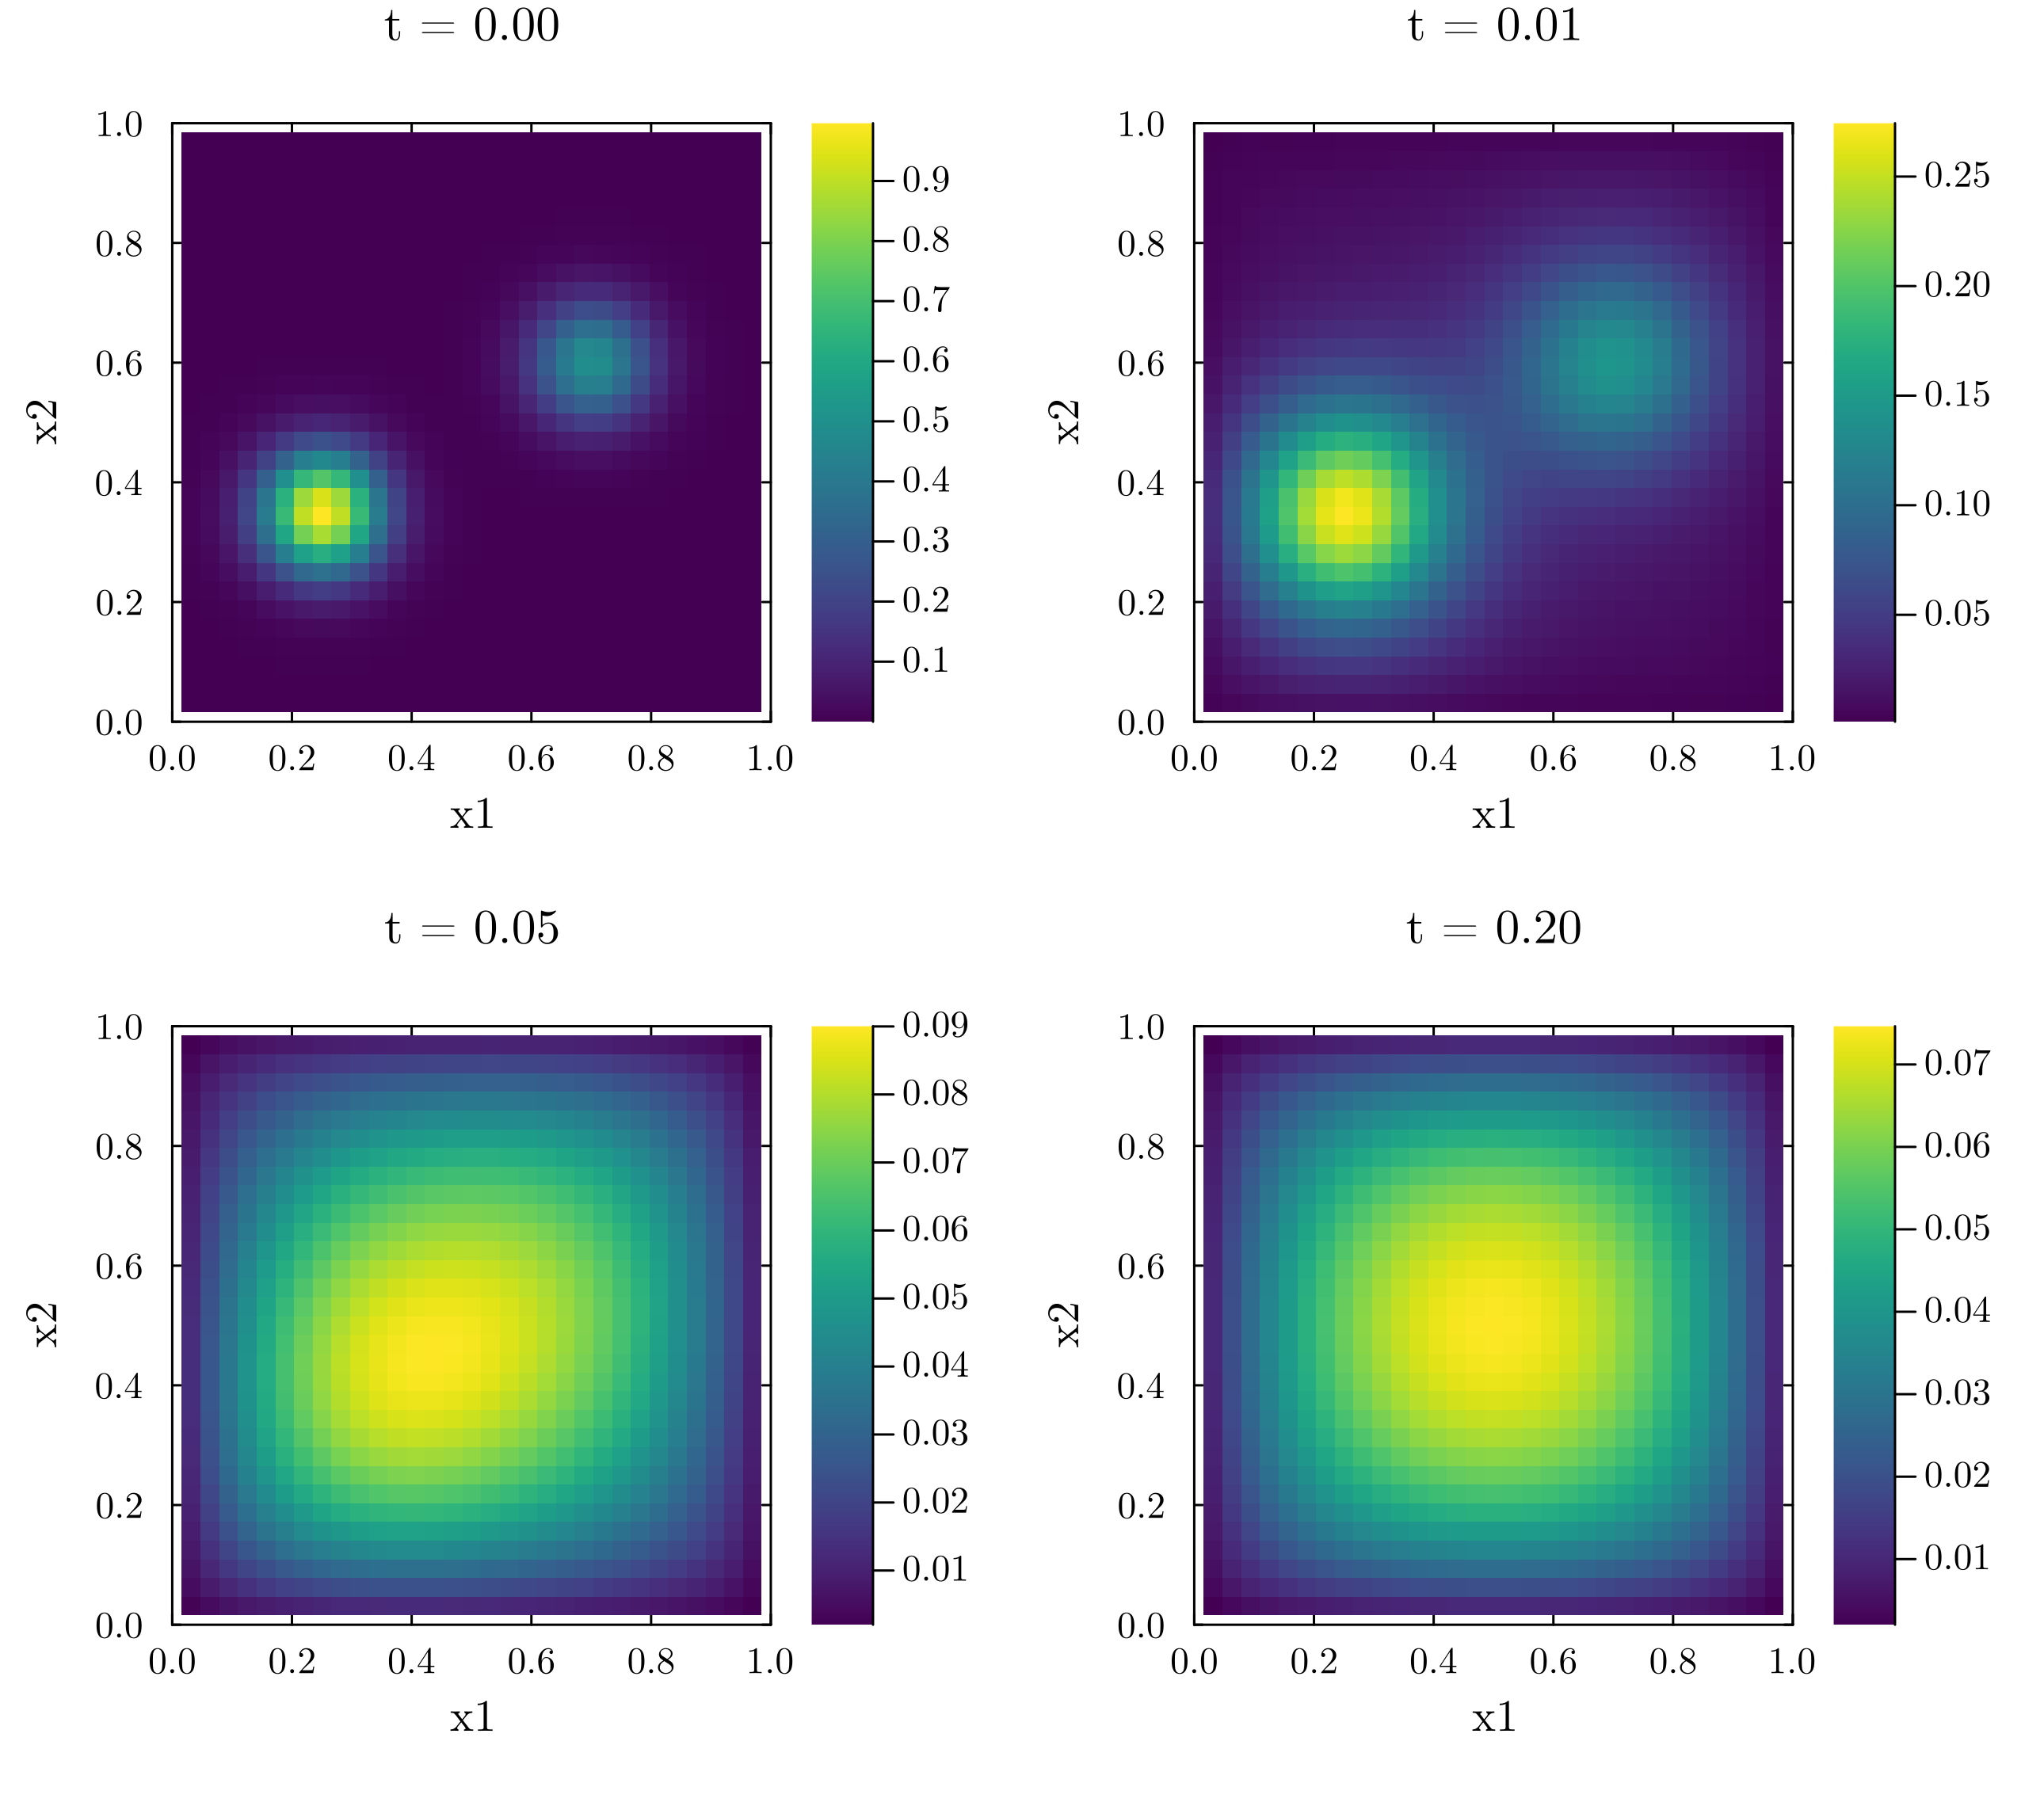

In [6]:
xs = range(1 / N, 1 - 1 / N; length = N - 1)
field(v) = reshape(v, N - 1, N - 1)'   # heatmap expects Z[j, i] = z(x[i], y[j])

snap_steps = [0, 2, 10, nsteps]
panels = [
  heatmap(
    xs,
    xs,
    field(snapshots[n]);
    title = @sprintf("t = %.2f", n * tau),
    color = :viridis,
    aspect_ratio = :equal,
    xlims = (0, 1),
    ylims = (0, 1),
    xlabel = "x1",
    ylabel = "x2",
  ) for n in snap_steps
]
fig1 = plot(panels...; layout = (2, 2), size = (860, 760), margin = 3mm)
savefigs(fig1, "heat_dd_snapshots")

## Figure 2: energy dissipation

Left: the free energy $J(u^n)$ decreases monotonically to the steady-state value $J(u_\infty)$,
as guaranteed by the minimizing-movements structure. Right: the gap $J(u^n) - J(u_\infty)$ decays
exponentially (straight line in the semi-log plot), at the rate of the smallest generalized
eigenvalue of $(K, M)$.

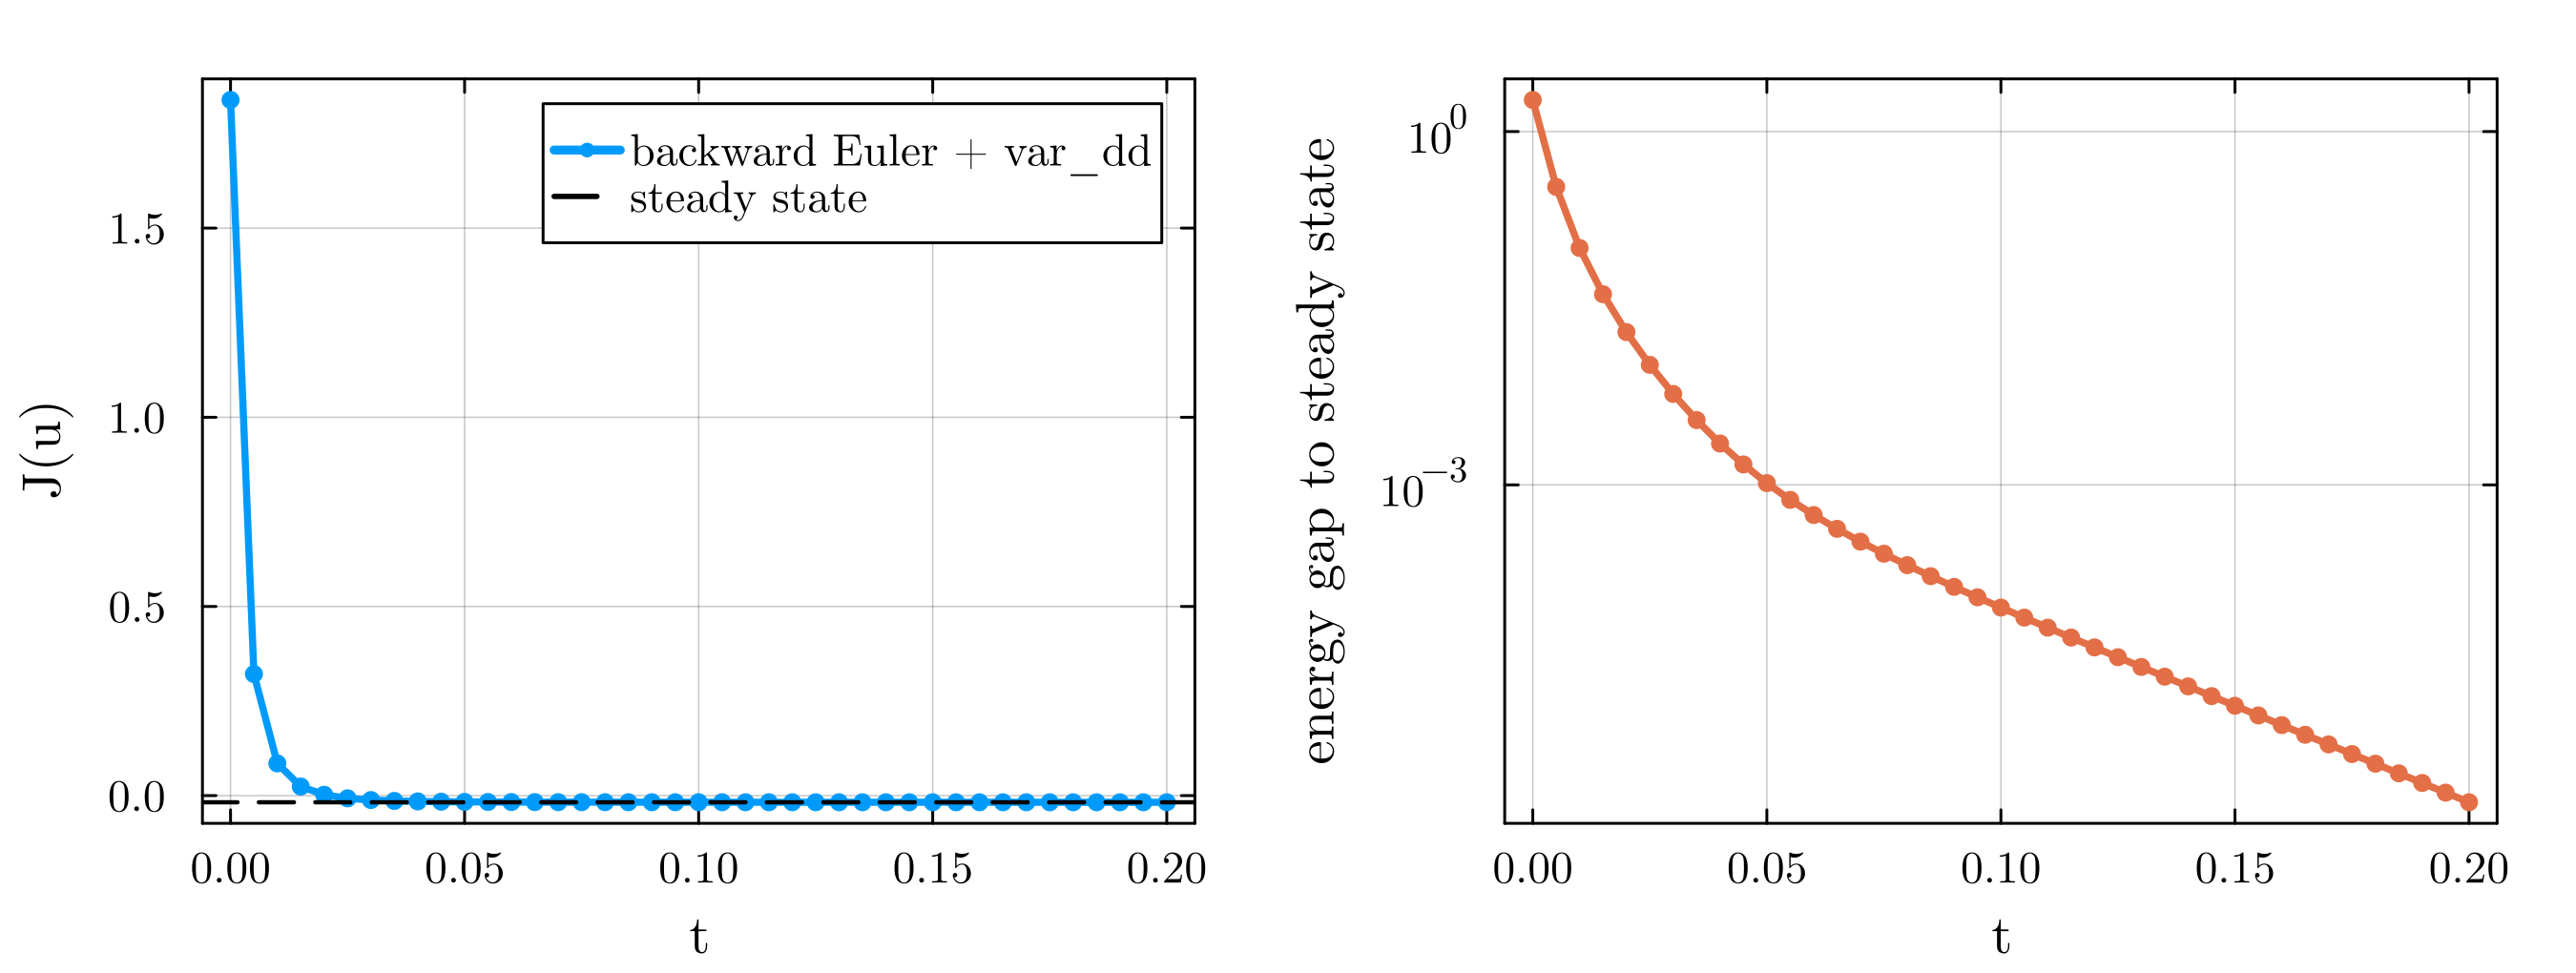

In [7]:
p1 = plot(
  ts,
  J_hist;
  xlabel = "t",
  ylabel = "J(u)",
  label = "backward Euler + var_dd",
  marker = :circle,
  markersize = 3.5,
  markerstrokewidth = 0,
  legend = :topright,
)
hline!(
  p1,
  [J_inf];
  label = "steady state",
  linestyle = :dash,
  linewidth = 1.5,
  color = :black,
)
p2 = plot(
  ts,
  J_hist .- J_inf;
  yscale = :log10,
  xlabel = "t",
  ylabel = "energy gap to steady state",
  label = "",
  marker = :circle,
  markersize = 3.5,
  markerstrokewidth = 0,
  color = 2,
)
fig2 = plot(p1, p2; layout = (1, 2), size = (900, 340), margin = 5mm)
savefigs(fig2, "heat_dd_energy")

## Figure 3: cost and accuracy per time step

Left: DD iterations needed per time step -- warm-starting from $u^n$ keeps the count low and it
drops further as the flow settles. Right: relative error of the DD trajectory against the direct
backward Euler reference stays at the solver tolerance; the time-discretization error is untouched.

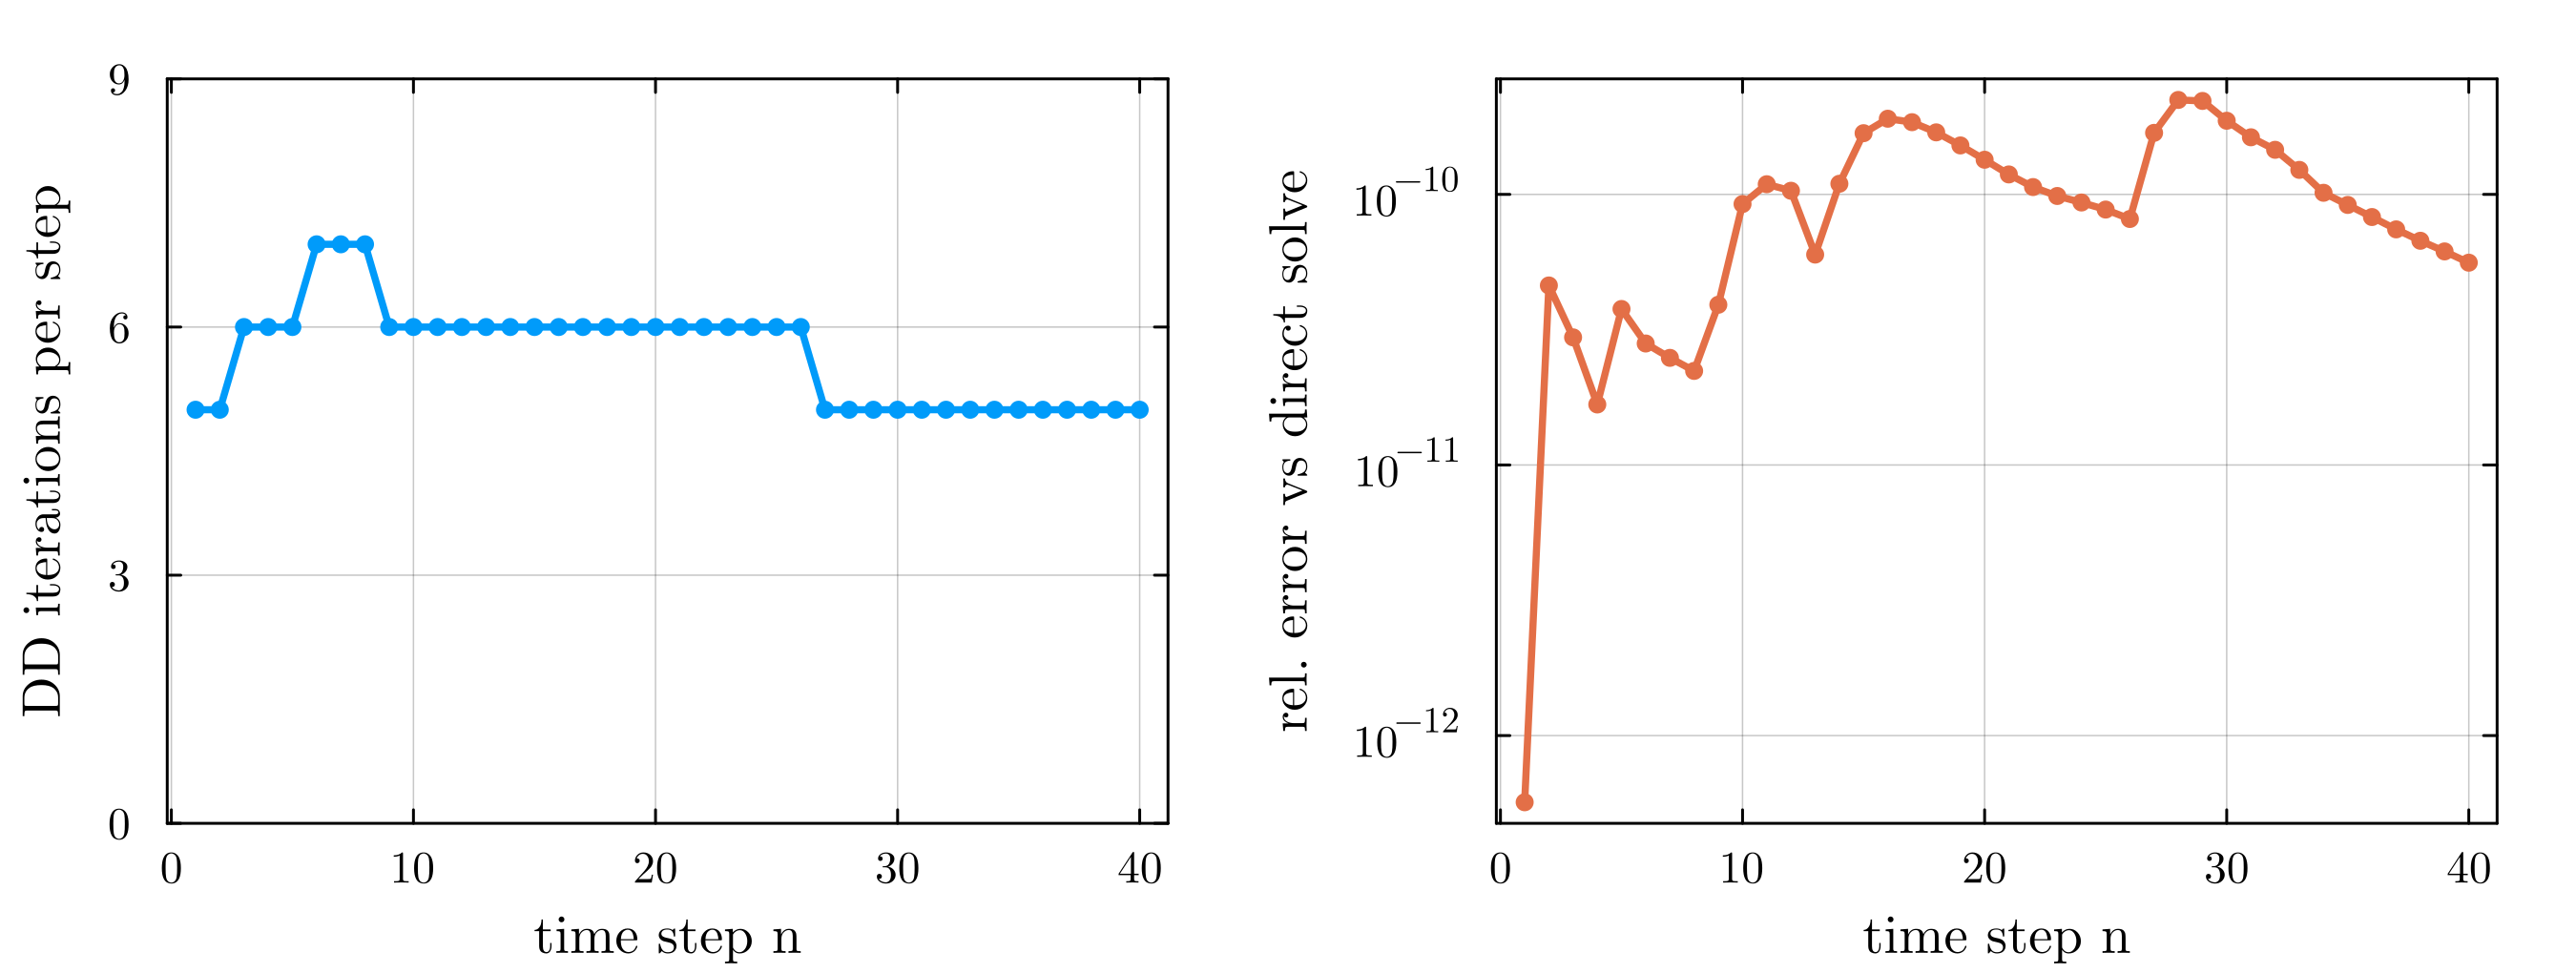

In [8]:
p1 = plot(
  1:nsteps,
  iters_hist;
  xlabel = "time step n",
  ylabel = "DD iterations per step",
  label = "",
  marker = :circle,
  markersize = 3.5,
  markerstrokewidth = 0,
  ylims = (0, maximum(iters_hist) + 2),
)
p2 = plot(
  1:nsteps,
  err_hist;
  yscale = :log10,
  xlabel = "time step n",
  ylabel = "rel. error vs direct solve",
  label = "",
  marker = :circle,
  markersize = 3.5,
  markerstrokewidth = 0,
  color = 2,
)
fig3 = plot(p1, p2; layout = (1, 2), size = (900, 340), margin = 5mm)
savefigs(fig3, "heat_dd_iterations")

## Figure 4: convergence within a time step

Residual norm of the incremental problem over the DD sweeps, for an early, a middle and the last
time step: the strong convexity added by the $M/\tau$ term gives a fast, essentially uniform linear
rate, and later steps start closer to the solution thanks to the warm start.

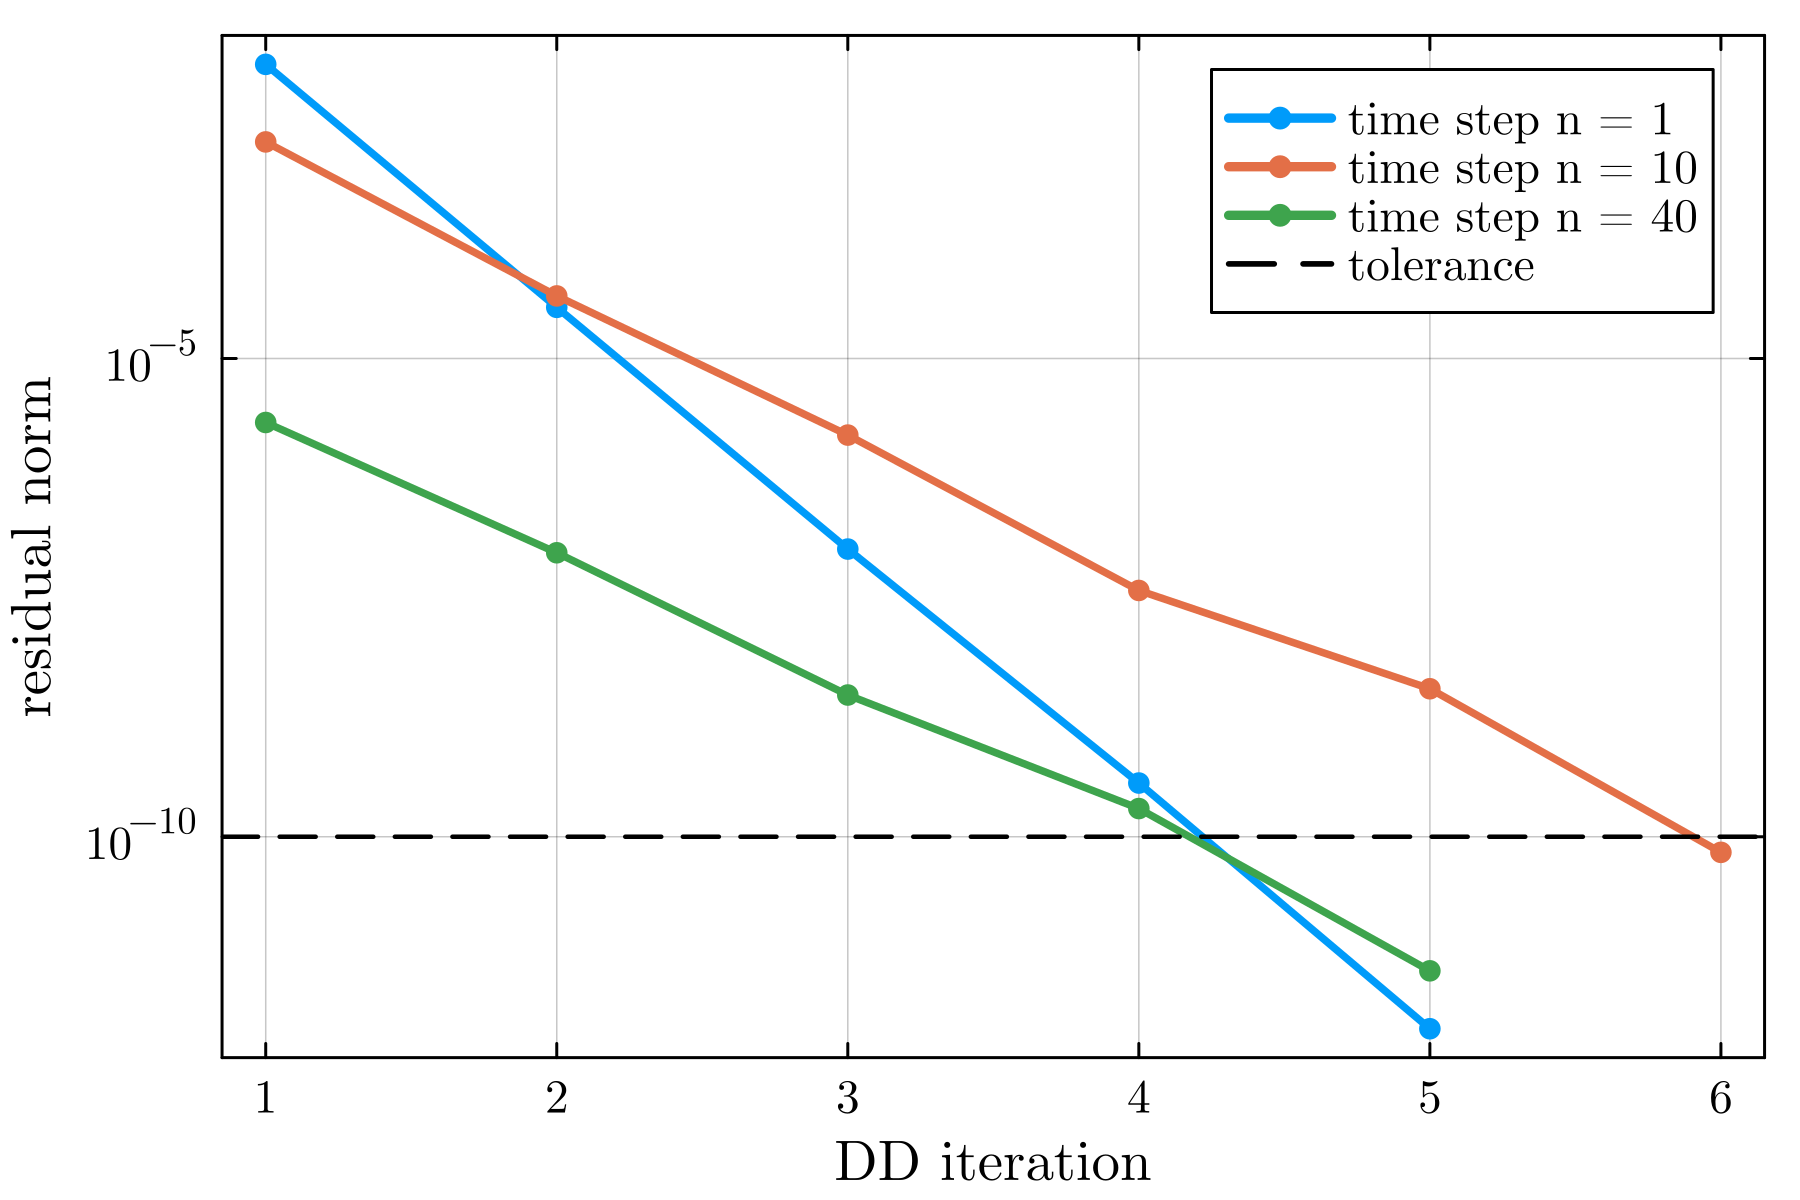

In [9]:
fig4 = plot(
  xlabel = "DD iteration",
  ylabel = "residual norm",
  yscale = :log10,
  legend = :topright,
  size = (600, 400),
)
for n in (1, 10, nsteps)
  plot!(
    fig4,
    1:length(res_hists[n]),
    res_hists[n];
    marker = :circle,
    markersize = 4,
    markerstrokewidth = 0,
    label = @sprintf("time step n = %d", n),
  )
end
hline!(
  fig4,
  [1e-10];
  label = "tolerance",
  linestyle = :dash,
  linewidth = 1.5,
  color = :black,
)
savefigs(fig4, "heat_dd_convergence")

## Remarks

- The scheme inherits **unconditional energy stability**: every `inf_step`/`combine_step` decreases
  $E_\tau$, hence $J(u^{n+1}) + \frac{1}{2\tau}\lVert u^{n+1}-u^n\rVert_M^2 \le J(u^n)$.
- The same construction applies verbatim to **nonlinear gradient flows** represented by
  `NonlinearEnergy`: for small $\tau$ the incremental problem is strongly convex even
  when $J$ is not.
- Natural extensions: subspace recycling of the `combine_step` coarse space across time steps, and
  adaptive $\tau$ based on the DD iteration count.